# Training a Classification Model on the German Traffic Sign Recognition Benchmark (GTSRB)

In [1]:
# --- Setup ---

# Pytorch
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import random_split
print("Using torch version " + str(torch.__version__))

# Others
import numpy as np
import matplotlib.pyplot as plt
import tqdm
import os

Using torch version 2.10.0+cu128


In [2]:
# --- Settings ---

# General run settings
running_on_colab = False
gtsrb_data_pth = os.path.join(os.getcwd(), "data", "gtsrb", "GTSRB")
if running_on_colab:
    training_results_pth = os.path.join(os.getcwd(), "drive", "MyDrive", "Colab Notebooks")
    attack_data_pth = os.path.join(os.getcwd(), "drive", "MyDrive", "Computer Vision", "data")
else:
    training_results_pth = os.path.join(os.getcwd(), "model")
    attack_data_pth = os.path.join(os.getcwd(), "physical_adv_attack", "generated")

# Set which parts to run
run_first_model = False
run_adversarial_training = False

# Configure seeds
torch_seed = 1234
np.random.seed(1234)

# Model and training settings
num_classes = 43
batch_size = 64
e2e_batch_size = 16

# Configure device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
if running_on_colab:
    from google.colab import drive
    drive.mount('/content/drive')

Notes:
The training set archive is structures as follows:
One directory per class
Each directory contains one CSV file with annotations ("GT-<ClassID>.csv") and the training images
Training images are grouped by tracks
Each track contains 30 images of one single physical traffic sign

In [4]:
class GTSRBDataLoader:
    def __init__(self):
        # We need to resize images because -> "Image sizes vary between 15x15 to 250x250 pixels"
        # mean = (0.3403, 0.3121, 0.3214), std = (0.2724, 0.2608, 0.2673)
        self.transform = transforms.Compose([
            transforms.Resize((250, 250)), # For pretrained AlexNet we need at least 224x224
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.3403, 0.3121, 0.3214], std=[0.2724, 0.2608, 0.2669]) # Normalize according to: https://github.com/tomlawrenceuk/GTSRB-Dataloader
        ])

        self.test_data = None
        self.train_data = None

    def load_GTSRB_data(self):
        # TEST
        self.test_data = datasets.GTSRB( # 12630 samples
            root="data",
            split="test",
            download=True,
            transform=self.transform,
        )
        print(f"Test data loaded: {len(self.test_data)} samples")

        # TRAIN
        self.train_data = datasets.GTSRB( # 26640 samples
            root="data",
            split="train",
            download=True,
            transform=self.transform,
        )

        self.train_size = int(0.8 * len(self.train_data))
        self.val_size = len(self.train_data) - self.train_size
        self.train_subset, self.val_subset = random_split(self.train_data, [self.train_size, self.val_size], generator=torch.Generator().manual_seed(torch_seed))
        print(f"Train data loaded: {len(self.train_data)} samples")

        # EVAL
        #self.eval_data = datasets.GTSRB(
        #    root="data",
        #    split="eval",
        #    download=True,
        #    transform=self.transform,
        #)

# Instantiate
gtsrb_loader = GTSRBDataLoader()
gtsrb_loader.load_GTSRB_data()

Test data loaded: 12630 samples
Train data loaded: 26640 samples


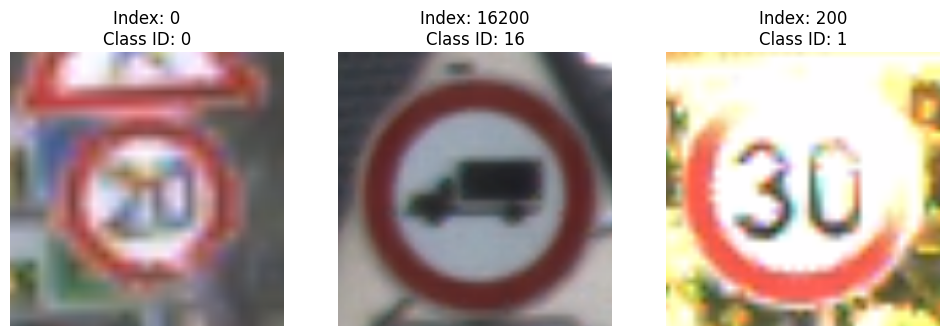

In [5]:
# To visualize images, we need to denormalize again
def visualize_images(dataset, indices):
    plt.figure(figsize=(12, 4))

    for i, idx in enumerate(indices):
        image, label = dataset[idx]

        # Denormalize (Reverse: x * std + mean)
        # mean = (0.3403, 0.3121, 0.3214), std = (0.2724, 0.2608, 0.2669)
        img = image.numpy().transpose((1, 2, 0)) # Convert from (C, H, W) to (H, W, C)
        mean = np.array([0.3403, 0.3121, 0.3214])
        std = np.array([0.2724, 0.2608, 0.2673])
        img = std * img + mean
        img = np.clip(img, 0, 1) # Ensure values are within [0, 1]

        plt.subplot(1, 3, i + 1)
        plt.imshow(img)
        plt.title(f"Index: {idx}\nClass ID: {label}")
        plt.axis('off')
    plt.show()

# Important to know: "GTSRB is organized by "tracks"—sequences of images of the same physical sign as the car drives toward it."
# So consecutive datapoints/images often look very similar & have same classId.
visualize_images(gtsrb_loader.train_data, [0, 16200, 200])

# AlexNet Architecture

In [6]:
# We have 43 classes (need to recheck that though)
# Got most of this from: https://www.digitalocean.com/community/tutorials/alexnet-pytorch
class AlexNet(nn.Module):
        def __init__(self, num_classes=43):
            super(AlexNet, self).__init__()
            self.layer1 = nn.Sequential(
                nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=0), # 3 input channels
                nn.BatchNorm2d(96),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size = 3, stride = 2))
            self.layer2 = nn.Sequential(
                nn.Conv2d(96, 256, kernel_size=5, stride=1, padding=2),
                nn.BatchNorm2d(256),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size = 3, stride = 2))
            self.layer3 = nn.Sequential(
                nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(384),
                nn.ReLU())
            self.layer4 = nn.Sequential(
                nn.Conv2d(384, 384, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(384),
                nn.ReLU())
            self.layer5 = nn.Sequential(
                nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(256),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size = 3, stride = 2))

            # Flattened size is 256 * 5 * 5 = 6400
            # Fact check this I dont really understand the dimensions of linear layer yet.
            self.fc = nn.Sequential(
                nn.Dropout(0.5),
                nn.Linear(6400, 4096),
                nn.ReLU())
            self.fc1 = nn.Sequential(
                nn.Dropout(0.5),
                nn.Linear(4096, 4096),
                nn.ReLU())
            self.fc2= nn.Sequential(
                nn.Linear(4096, num_classes))

        def forward(self, x):
            out = self.layer1(x)
            out = self.layer2(out)
            out = self.layer3(out)
            out = self.layer4(out)
            out = self.layer5(out)
            out = out.reshape(out.size(0), -1)
            out = self.fc(out)
            out = self.fc1(out)
            out = self.fc2(out)
            return out

In [7]:
model = AlexNet(num_classes).to(device)

# Hyperparameters

In [8]:
import pandas as pd

def training_loop(model, device, train_loader, valid_loader, training_fname, folder, num_epochs=20):
  # Loss and optimizer
  criterion = nn.CrossEntropyLoss()
  #optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay = 0.005, momentum = 0.9)
  optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


  training_df = pd.DataFrame(columns=["Epoch", "Loss", "Val Acc"])
  for epoch in range(num_epochs):
      # Training Phase
      model.train() # Set to train mode
      running_loss = 0.0

      train_bar = tqdm.tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Train")

      for i, (images, labels) in enumerate(train_bar):
          images, labels = images.to(device), labels.to(device)

          outputs = model(images)
          loss = criterion(outputs, labels)

          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

          running_loss += loss.item()
          train_bar.set_postfix(loss=loss.item())

      # Validation Phase
      model.eval()
      correct = 0
      total = 0

      val_bar = tqdm.tqdm(valid_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Valid", leave=False)

      with torch.no_grad():
          for images, labels in val_bar:
              images, labels = images.to(device), labels.to(device)
              outputs = model(images)
              _, predicted = torch.max(outputs.data, 1)
              total += labels.size(0)
              correct += (predicted == labels).sum().item()

      accuracy = 100 * correct / total
      print(f'Done Epoch [{epoch+1}/{num_epochs}] | Loss: {running_loss/len(train_loader):.4f} | Val Acc: {accuracy:.2f}%')

      training_df.loc[epoch] = [epoch, running_loss / len(train_loader), accuracy]
      training_df.to_csv(os.path.join(folder, training_fname + ".csv"), index=False)

      torch.save(model.state_dict(), os.path.join(folder, training_fname + ".pth"))

In [9]:
if run_first_model:
  train_loader = torch.utils.data.DataLoader(gtsrb_loader.train_subset, batch_size=batch_size, shuffle=True)
  valid_loader = torch.utils.data.DataLoader(gtsrb_loader.val_subset, batch_size=batch_size, shuffle=True)

  training_loop(model, device, train_loader, valid_loader, "first_model_weights", training_results_pth)

# Evaluate

In [10]:
def test_model(model):
    model.eval() # set to eval mode

    test_loader = torch.utils.data.DataLoader(gtsrb_loader.test_data, batch_size=batch_size, shuffle=False)

    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for images, labels in tqdm.tqdm(test_loader, desc="Testing"):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs.data, 1)

            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    test_accuracy = 100 * test_correct / test_total
    print(f'\n===============================')
    print(f'Final Test Accuracy: {test_accuracy:.2f}%')
    print(f'===============================')

In [11]:
if run_first_model:
    test_model(model)

# Adversarial Defences

## Adversarial Training

In [12]:
from torch.utils.data import Dataset
from PIL import Image

In [13]:
class ImageProperties():
  def __init__(self, fname, fclass, train=True):
    self.fname = fname
    self.fclass = fclass
    self.train = train

  def get_fpath_initial(self):
    if self.train:
      return os.path.join(gtsrb_data_pth, "Training", f"{self.fclass:05d}", self.fname + ".ppm")
    else:
      return os.path.join(gtsrb_data_pth, "Final_Test", "Images", self.fname + ".ppm")

  def get_fpath_attack(self, attack):
    # If runnning on Colab, use old filename structure
    prefix = f"{self.fclass:05d}_" if running_on_colab else ""

    return os.path.join(attack_data_pth, "train" if self.train else "test", attack, f"{self.fclass:02d}", f"{prefix}{self.fname}_{attack}_00.png")

  def get_fname(self):
    return self.fname

  def get_fclass(self):
    return self.fclass

In [14]:
# Reference: https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html#creating-a-custom-dataset-for-your-files
class AdversarialTrainingDataset(Dataset):
    def __init__(self, transform, ratio, train_files: list[ImageProperties], attack_name="shadow"):
      self.transform = transform
      self.train_files = train_files
      self.attack_name = attack_name
      self.attack_dir = os.path.join(attack_data_pth, "train", self.attack_name)
      self.length = len(self.train_files)

      # Generate a random split between adversarial and non-adversarial data
      max_idx = int(self.length * ratio)
      self.non_adv_adv_split = np.full((self.length,), False)
      self.non_adv_adv_split[:max_idx] = True
      np.random.shuffle(self.non_adv_adv_split)

    def __len__(self):
      return self.length

    def __getitem__(self, idx):
      img_props = self.train_files[idx]
      img_path = img_props.get_fpath_initial() if self.non_adv_adv_split[idx] else img_props.get_fpath_attack(self.attack_name)
      img = Image.open(img_path)
      transformed_img = self.transform(img)
      return transformed_img, img_props.get_fclass()

In [15]:
def adversarial_training(ratio, attack_name="shadow"):
  # Build data structure to easily access training file properties
  train_files = []
  train_pth = os.path.join(gtsrb_data_pth, "Training")
  for folder in os.listdir(train_pth):
    if os.path.isfile(os.path.join(train_pth, folder)):
      continue

    for img in os.listdir(os.path.join(train_pth, folder)):
      if not ".ppm" in img:
        continue

      train_files.append(ImageProperties(img.split(".")[0], int(folder)))

  train_data = AdversarialTrainingDataset(gtsrb_loader.transform, ratio, train_files, attack_name)
  train_subset, val_subset = random_split(train_data, [gtsrb_loader.train_size, gtsrb_loader.val_size], generator=torch.Generator().manual_seed(torch_seed))

  train_loader = torch.utils.data.DataLoader(train_subset, batch_size=batch_size, shuffle=True)
  valid_loader = torch.utils.data.DataLoader(val_subset, batch_size=batch_size, shuffle=True)

  training_loop(model, device, train_loader, valid_loader, training_fname=f"adv_training_{ratio}_{attack_name}", folder=training_results_pth)

In [16]:
if run_adversarial_training:
  adversarial_training(0.5, "occlusion")

---
# Adversarial Detection Pipeline

Full pipeline: **Attack Classifier → Learned Denoiser → Soft Blend → AlexNet**

Two evaluation modes:
- **Approach A** — modules loaded from their individual pre-trained weights (no joint training)
- **Approach B** — end-to-end fine-tuned from those same weights

Phases:
1. Train / load **Attack Classifier**
2. Train / load **Learned Denoiser**
3. Assemble **Pipeline A** (frozen)
4. Fine-tune **Pipeline B** end-to-end
5. Evaluate and generate report figures

In [17]:
# --- Flags: set True to retrain, False to load saved weights ---
run_attack_classifier_training = False
run_denoiser_training          = False
run_e2e_training               = True
auto_prepare_e2e_data         = True
force_regenerate_attack_data  = False

detection_attack_name = "occlusion"
preferred_alexnet_weights = "adv_training_0.5_occlusion.pth"
dataset_root   = os.path.join(os.getcwd(), "data", "gtsrb")
manifest_path  = os.path.join(os.getcwd(), "physical_adv_attack", "generated", "manifest.csv")
config_path    = os.path.join(os.getcwd(), "physical_adv_attack", "config.yaml")


In [18]:
import importlib, copy
import architectures
import attack_classifier as _ac_mod
import attack_detection_dataset as _add_mod
import notebook_setup as _nb_setup
import pipeline as _pl_mod
importlib.reload(architectures)
importlib.reload(_ac_mod)
importlib.reload(_add_mod)
importlib.reload(_nb_setup)
importlib.reload(_pl_mod)

from architectures import AlexNet, LearnedDenoiser
from attack_classifier import AttackClassifier
from attack_detection_dataset import AttackDetectionDataset, DenoiserDataset, E2EDataset
from notebook_setup import prepare_notebook_environment, format_generation_summary
from pipeline import (
    AdversarialRobustnessPipeline,
    train_attack_classifier, train_denoiser, train_end_to_end,
)
from torch.utils.data import DataLoader, random_split
import pandas as pd
from IPython.display import clear_output
from PIL import Image as PILImage
print('All modules loaded')


All modules loaded


## Utilities

## Auto-Prepare E2E Assets

In [19]:
def make_training_callback(title, metric_groups):
    """
    Returns a callback(history) that re-draws a live plot after every epoch.
    metric_groups: list of (keys_list, ylabel, subtitle)
    """
    def callback(history):
        clear_output(wait=True)
        n = len(metric_groups)
        fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
        if n == 1:
            axes = [axes]
        epochs = [h['epoch'] for h in history]
        for ax, (keys, ylabel, subtitle) in zip(axes, metric_groups):
            for key in keys:
                ax.plot(epochs, [h[key] for h in history], label=key, marker='o', markersize=3)
            ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel); ax.set_title(subtitle)
            ax.legend(); ax.grid(True, alpha=0.3)
        fig.suptitle(title, fontweight='bold')
        plt.tight_layout(); plt.show()
        if history:
            last = history[-1]
            print(' | '.join(
                f"{k}={v:.4f}" if isinstance(v, float) else f"{k}={v}"
                for k, v in last.items()
            ))
    return callback

# GTSRB denorm (for display)
_MEAN = torch.tensor([0.3403, 0.3121, 0.3214]).view(3, 1, 1)
_STD  = torch.tensor([0.2724, 0.2608, 0.2669]).view(3, 1, 1)

def denorm(t):
    """(C,H,W) normalised tensor -> [0,1] clipped for display."""
    return (t.cpu() * _STD + _MEAN).clamp(0, 1)

def psnr(mse, max_val=1.0):
    import math
    return float('inf') if mse == 0 else 10 * math.log10(max_val ** 2 / mse)

print('Utilities ready')


Utilities ready


In [20]:
prepared = prepare_notebook_environment(
    project_root=os.getcwd(),
    dataset_root=dataset_root,
    manifest_path=manifest_path,
    config_path=config_path,
    attack_name=detection_attack_name,
    auto_prepare_data=auto_prepare_e2e_data,
    force_regenerate=force_regenerate_attack_data,
    alexnet_weights_name=preferred_alexnet_weights,
)

dataset_root = prepared['dataset_root']
manifest_path = prepared['manifest_path']
weight_paths = prepared['weight_paths']
attack_clf_path = weight_paths['attack_classifier']
denoiser_path = weight_paths['denoiser']
alexnet_path = weight_paths['alexnet']
e2e_path = weight_paths['pipeline_e2e'] or os.path.join(os.getcwd(), 'model', 'pipeline_e2e.pth')

print('Prepared notebook assets:')
print(f"  dataset_root        : {dataset_root}")
print(f"  manifest_path       : {manifest_path}")
print(f"  alexnet weights     : {alexnet_path}")
print(f"  attack clf weights  : {attack_clf_path}")
print(f"  denoiser weights    : {denoiser_path}")
print(f"  pipeline e2e weights: {e2e_path} {'(will be created on first e2e run)' if not os.path.exists(e2e_path) else ''}")
print('\nDataset generation status:')
print(format_generation_summary(prepared['generation_summary']))


Prepared notebook assets:
  dataset_root        : /home/jgilaviles/computer_vision/computer-vision-project/data/gtsrb
  manifest_path       : /home/jgilaviles/computer_vision/computer-vision-project/physical_adv_attack/generated/manifest.csv
  alexnet weights     : /home/jgilaviles/computer_vision/computer-vision-project/model/adv_training_0.5_occlusion.pth
  attack clf weights  : /home/jgilaviles/computer_vision/computer-vision-project/model/attack_classifier.pth
  denoiser weights    : /home/jgilaviles/computer_vision/computer-vision-project/model/denoiser.pth
  pipeline e2e weights: /home/jgilaviles/computer_vision/computer-vision-project/model/pipeline_e2e.pth (will be created on first e2e run)

Dataset generation status:
Existing generated attack dataset will be reused.


## Dataset Verification

Manifest rows : 26,640
Splits        : {'train': 26640}
Attacks       : {'occlusion': 26640}
Classes       : 43 unique sign classes
PyTorch test  : 12,630 clean test samples


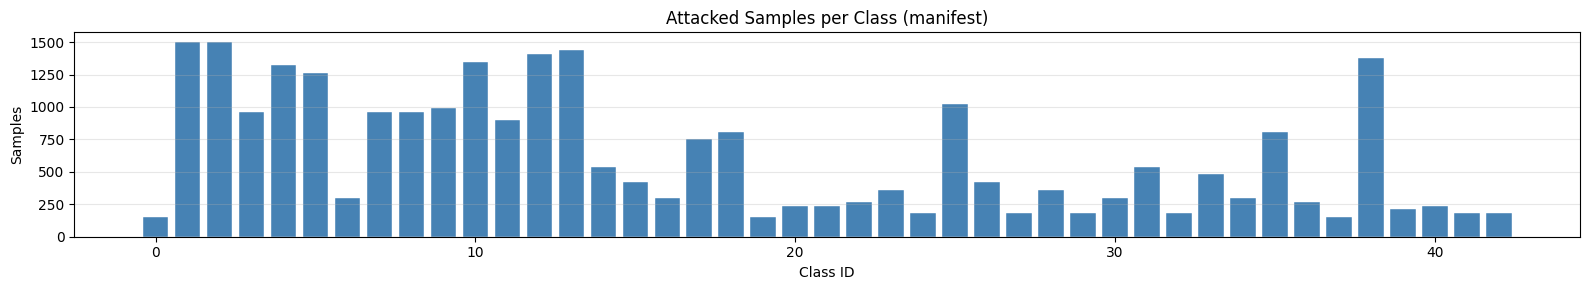

In [21]:
df_manifest = pd.read_csv(manifest_path)
print(f"Manifest rows : {len(df_manifest):,}")
print(f"Splits        : {df_manifest['split'].value_counts().to_dict()}")
print(f"Attacks       : {df_manifest['attack'].value_counts().to_dict()}")
print(f"Classes       : {df_manifest['class_id'].nunique()} unique sign classes")
print(f"PyTorch test  : {len(gtsrb_loader.test_data):,} clean test samples")

# Class distribution
fig, ax = plt.subplots(figsize=(16, 3))
cc = df_manifest['class_id'].value_counts().sort_index()
ax.bar(cc.index, cc.values, color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_xlabel('Class ID'); ax.set_ylabel('Samples')
ax.set_title('Attacked Samples per Class (manifest)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


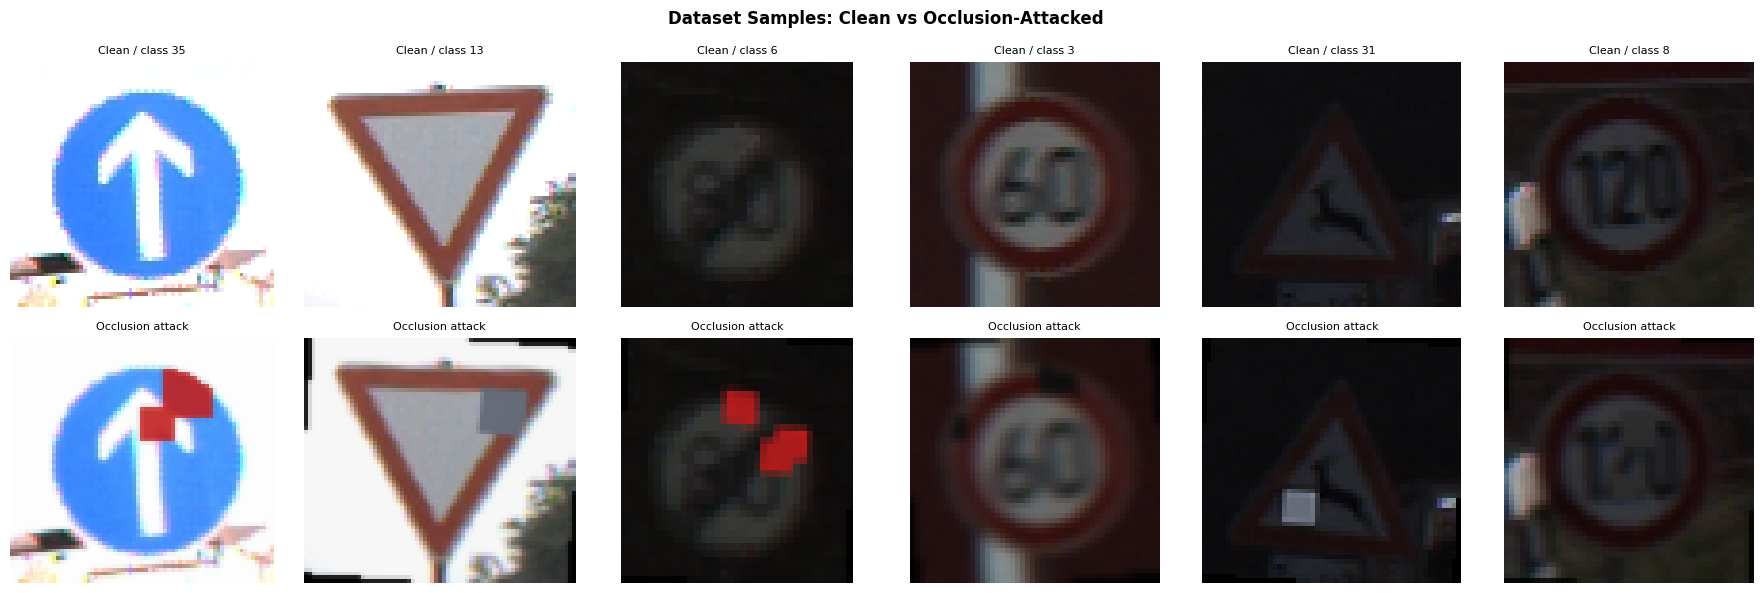

In [22]:
# Visual: Original vs Attacked side-by-side
output_root = os.path.dirname(manifest_path)
sample_rows = df_manifest.sample(6, random_state=42)

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for col, (_, row) in enumerate(sample_rows.iterrows()):
    orig_img = PILImage.open(os.path.join(dataset_root, str(row['original_path']))).convert('RGB')
    atk_img  = PILImage.open(os.path.join(output_root,  str(row['output_path']))).convert('RGB')
    axes[0, col].imshow(orig_img)
    axes[0, col].set_title(f"Clean / class {row['class_id']}", fontsize=8)
    axes[0, col].axis('off')
    axes[1, col].imshow(atk_img)
    axes[1, col].set_title('Occlusion attack', fontsize=8)
    axes[1, col].axis('off')

fig.suptitle('Dataset Samples: Clean vs Occlusion-Attacked', fontweight='bold')
plt.tight_layout(); plt.show()


## Data Loaders

## Build Training Datasets

In [23]:
# Build the three full datasets used by the end-to-end workflow.
# This is the only data block you need before training or loading the pipeline modules.
full_det = AttackDetectionDataset(
    manifest_path, attack_name=detection_attack_name,
    split="train", dataset_root=dataset_root
)
full_dn = DenoiserDataset(
    manifest_path, attack_name=detection_attack_name,
    split="train", dataset_root=dataset_root
)
full_e2e = E2EDataset(
    manifest_path, attack_name=detection_attack_name,
    split="train", dataset_root=dataset_root
)

dataset_overview = pd.DataFrame([
    {"Dataset": "AttackClassifier", "Samples": len(full_det), "Target": "clean vs attacked"},
    {"Dataset": "LearnedDenoiser",  "Samples": len(full_dn),  "Target": "attacked -> clean"},
    {"Dataset": "Pipeline E2E",      "Samples": len(full_e2e), "Target": "sign class + attack label"},
])
display(dataset_overview)


,Dataset,Samples,Target
0,AttackClassifier,53280,clean vs attacked
1,LearnedDenoiser,26640,attacked -> clean
2,Pipeline E2E,53280,sign class + attack label


In [24]:
_SEED = torch.Generator().manual_seed(1234)

_n = int(0.2 * len(full_det))
det_train_ds, det_val_ds = random_split(full_det, [len(full_det)-_n, _n], generator=_SEED)
det_train_loader = DataLoader(det_train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
det_val_loader   = DataLoader(det_val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
print(f"Attack classifier : {len(det_train_ds):,} train / {len(det_val_ds):,} val")

_n = int(0.2 * len(full_dn))
dn_train_ds, dn_val_ds = random_split(full_dn, [len(full_dn)-_n, _n], generator=_SEED)
dn_train_loader = DataLoader(dn_train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
dn_val_loader   = DataLoader(dn_val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
print(f"Denoiser          : {len(dn_train_ds):,} train / {len(dn_val_ds):,} val")

_n = int(0.2 * len(full_e2e))
e2e_train_ds, e2e_val_ds = random_split(full_e2e, [len(full_e2e)-_n, _n], generator=_SEED)
e2e_train_loader = DataLoader(e2e_train_ds, batch_size=e2e_batch_size, shuffle=True,  num_workers=2, pin_memory=True)
e2e_val_loader   = DataLoader(e2e_val_ds,   batch_size=e2e_batch_size, shuffle=False, num_workers=2, pin_memory=True)
print(f"E2E               : {len(e2e_train_ds):,} train / {len(e2e_val_ds):,} val  | batch_size={e2e_batch_size}")


Attack classifier : 42,624 train / 10,656 val
Denoiser          : 21,312 train / 5,328 val
E2E               : 42,624 train / 10,656 val


## Phase 1: Attack Classifier

Light CNN (3 conv blocks + AdaptiveAvgPool) → single logit, trained with BCEWithLogitsLoss.  
Binary: **0 = clean**, **1 = attacked**.

Loaded attack classifier from /home/jgilaviles/computer_vision/computer-vision-project/model/attack_classifier.pth


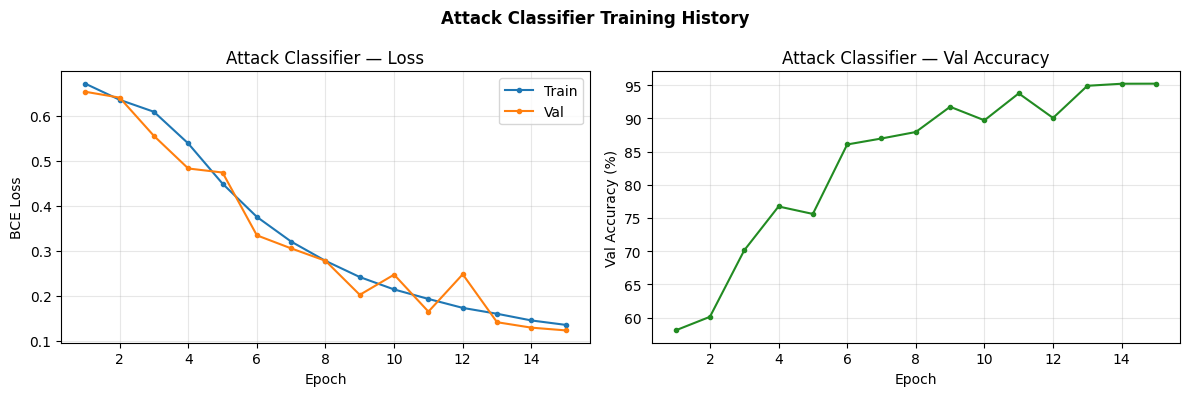

Best val acc: 95.23% at epoch 15


In [25]:
attack_clf = AttackClassifier().to(device)

if run_attack_classifier_training:
    clf_cb = make_training_callback(
        "Attack Classifier Training",
        [
            (['train_loss', 'val_loss'], 'BCE Loss',    'Loss curves'),
            (['val_acc'],               'Accuracy (%)', 'Validation accuracy'),
        ]
    )
    clf_hist = train_attack_classifier(
        attack_clf, det_train_loader, det_val_loader, device,
        num_epochs=15, lr=1e-3, save_path=attack_clf_path, callback=clf_cb,
    )
    pd.DataFrame(clf_hist).to_csv(
        os.path.join(os.getcwd(), "model", "attack_classifier_history.csv"), index=False
    )
else:
    attack_clf.load_state_dict(torch.load(attack_clf_path, map_location=device, weights_only=True))
    print(f"Loaded attack classifier from {attack_clf_path}")

# Plot saved training curves
_clf_csv = os.path.join(os.getcwd(), "model", "attack_classifier_history.csv")
if os.path.exists(_clf_csv):
    _h = pd.read_csv(_clf_csv)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(_h['epoch'], _h['train_loss'], label='Train', marker='o', markersize=3)
    ax1.plot(_h['epoch'], _h['val_loss'],   label='Val',   marker='o', markersize=3)
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss')
    ax1.set_title('Attack Classifier — Loss'); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(_h['epoch'], _h['val_acc'], color='forestgreen', marker='o', markersize=3)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val Accuracy (%)')
    ax2.set_title('Attack Classifier — Val Accuracy'); ax2.grid(alpha=0.3)
    plt.suptitle('Attack Classifier Training History', fontweight='bold')
    plt.tight_layout(); plt.show()
    print(f"Best val acc: {_h['val_acc'].max():.2f}% at epoch {int(_h['val_acc'].idxmax()) + 1}")


## Phase 2: Learned Denoiser

U-Net style autoencoder with skip connections and GELU activations.  
Trained with MSE loss on **(attacked image → clean image)** pairs.  
Uses **residual learning**: output = input + learned correction.  
Based on *Defense Against Adversarial Attacks using Convolutional Auto-Encoders* (arXiv 2312.03520).

In [26]:
denoiser = LearnedDenoiser().to(device)

if run_denoiser_training:
    dn_cb = make_training_callback(
        "Denoiser Training",
        [(['train_loss', 'val_loss'], 'MSE Loss', 'Reconstruction Loss')]
    )
    dn_hist = train_denoiser(
        denoiser, dn_train_loader, dn_val_loader, device,
        num_epochs=20, lr=1e-3, save_path=denoiser_path, callback=dn_cb,
    )
    pd.DataFrame(dn_hist).to_csv(
        os.path.join(os.getcwd(), "model", "denoiser_history.csv"), index=False
    )
else:
    denoiser.load_state_dict(torch.load(denoiser_path, map_location=device, weights_only=True))
    print(f"Loaded denoiser from {denoiser_path}")

_dn_csv = os.path.join(os.getcwd(), "model", "denoiser_history.csv")
if os.path.exists(_dn_csv):
    _h = pd.read_csv(_dn_csv)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(_h['epoch'], _h['train_loss'], label='Train MSE', marker='o', markersize=3)
    ax.plot(_h['epoch'], _h['val_loss'],   label='Val MSE',   marker='o', markersize=3)
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
    ax.set_title('Denoiser — Reconstruction Loss'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    print(f"Best val MSE: {_h['val_loss'].min():.6f} at epoch {int(_h['val_loss'].idxmin()) + 1}")


Loaded denoiser from /home/jgilaviles/computer_vision/computer-vision-project/model/denoiser.pth


## Approach A — Pre-trained Pipeline

Each module loaded from its individually-trained weights. No joint optimisation.

In [27]:
sign_clf = AlexNet(num_classes).to(device)
sign_clf.load_state_dict(torch.load(alexnet_path, map_location=device, weights_only=True))

pipeline_a = AdversarialRobustnessPipeline(
    sign_clf, attack_clf, gaussian_denoiser=denoiser
).to(device)
pipeline_a.eval()

print(f"AlexNet          : {alexnet_path}")
print(f"AttackClassifier : {attack_clf_path}")
print(f"LearnedDenoiser  : {denoiser_path}")
print("Pipeline A assembled (pre-trained, no e2e fine-tuning)")


AlexNet          : /home/jgilaviles/computer_vision/computer-vision-project/model/adv_training_0.5_occlusion.pth
AttackClassifier : /home/jgilaviles/computer_vision/computer-vision-project/model/attack_classifier.pth
LearnedDenoiser  : /home/jgilaviles/computer_vision/computer-vision-project/model/denoiser.pth
Pipeline A assembled (pre-trained, no e2e fine-tuning)


## Approach B — End-to-End Fine-tuning

Starts from Pipeline A weights and jointly optimises all modules:

```
L_total = CrossEntropy(sign) + λ · BCE(attack detection)
```

In [28]:
pipeline_b = copy.deepcopy(pipeline_a).to(device)

if run_e2e_training:
    e2e_cb = make_training_callback(
        "End-to-End Pipeline Training",
        [
            (['total_loss'],          'Combined Loss', 'E2E Loss'),
            (['sign_acc', 'det_acc'], 'Accuracy (%)',  'Sign & Detection Accuracy'),
        ]
    )
    e2e_hist = train_end_to_end(
        pipeline_b, e2e_train_loader, e2e_val_loader, device,
        num_epochs=10, lr=1e-4, lambda_det=0.5,
        save_path=e2e_path, callback=e2e_cb,
    )
    pd.DataFrame(e2e_hist).to_csv(
        os.path.join(os.getcwd(), "model", "pipeline_e2e_history.csv"), index=False
    )
else:
    if os.path.exists(e2e_path):
        pipeline_b.load_state_dict(torch.load(e2e_path, map_location=device, weights_only=True))
        print(f"Loaded e2e pipeline from {e2e_path}")
    else:
        print("No e2e weights found — Pipeline B = Pipeline A. Set run_e2e_training=True to train.")

_e2e_csv = os.path.join(os.getcwd(), "model", "pipeline_e2e_history.csv")
if os.path.exists(_e2e_csv):
    _h = pd.read_csv(_e2e_csv)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(_h['epoch'], _h['total_loss'], color='purple', marker='o', markersize=3)
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title('E2E — Combined Loss'); ax1.grid(alpha=0.3)
    ax2.plot(_h['epoch'], _h['sign_acc'], label='Sign Acc', marker='o', markersize=3)
    ax2.plot(_h['epoch'], _h['det_acc'],  label='Det Acc',  marker='o', markersize=3)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('E2E — Accuracy'); ax2.legend(); ax2.grid(alpha=0.3)
    plt.suptitle('End-to-End Training History', fontweight='bold')
    plt.tight_layout(); plt.show()

pipeline_b.eval()
print("Pipeline B ready")


No e2e weights found — Pipeline B = Pipeline A. Set run_e2e_training=True to train.
Pipeline B ready


---
## Evaluation: AlexNet Sign Classifier

Accuracy, confusion matrix, and per-class bar chart on the clean GTSRB test set (12,630 images).

AlexNet eval: 100%|██████████| 198/198 [00:13<00:00, 14.65it/s]


AlexNet accuracy on clean GTSRB test set: 97.67%


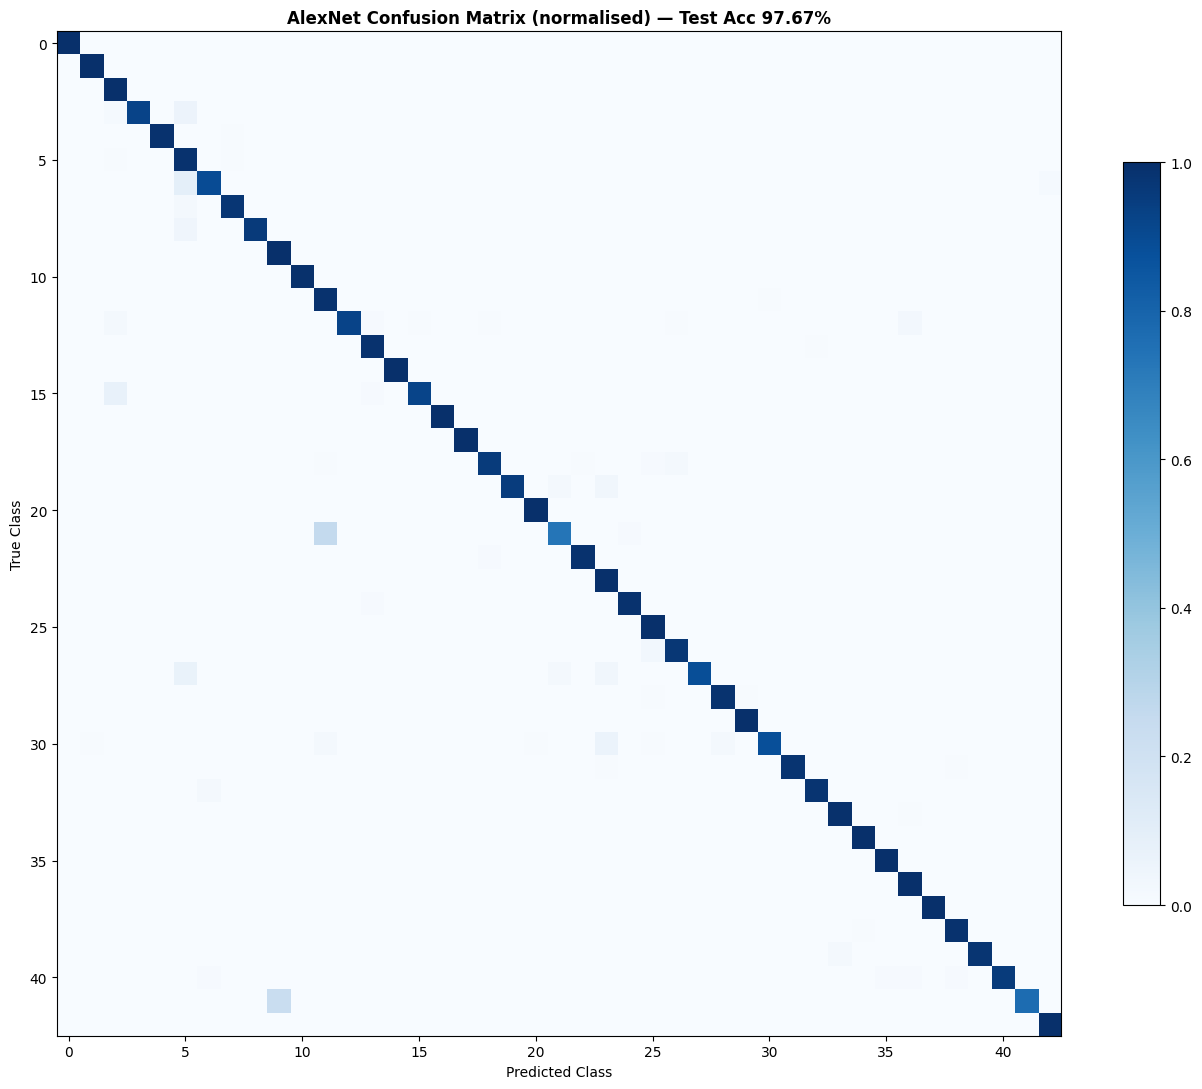

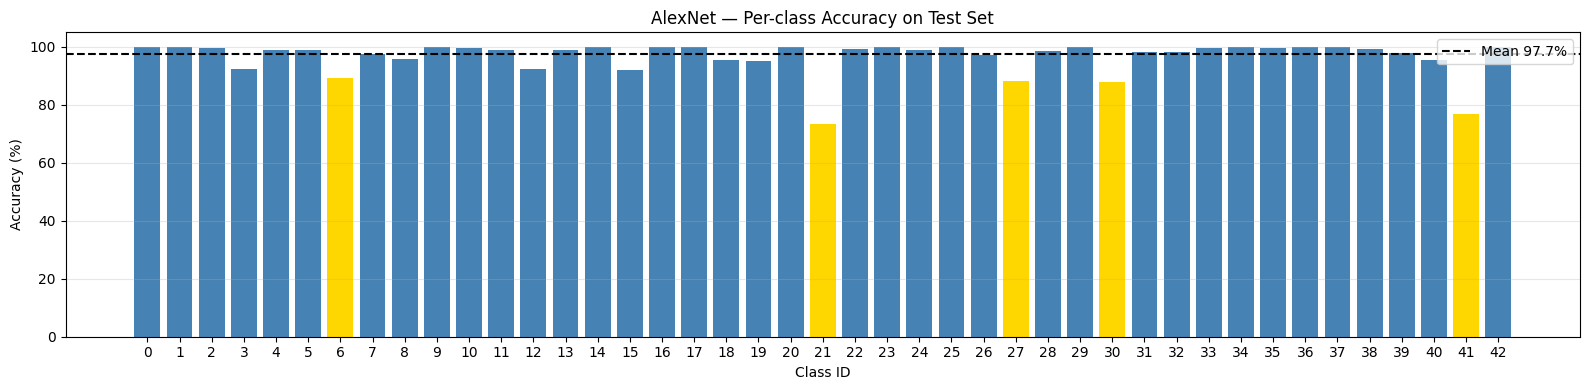

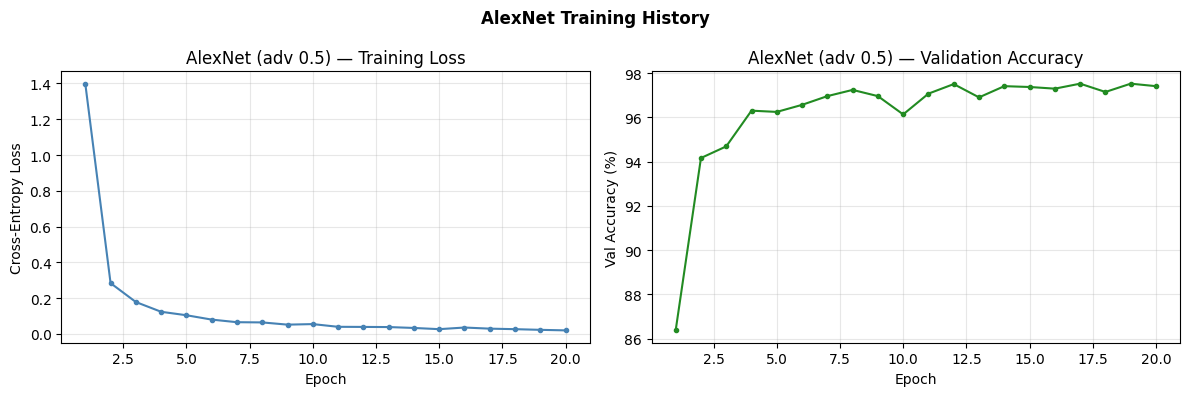

In [29]:
from sklearn.metrics import confusion_matrix
import numpy as np

test_loader_clean = DataLoader(gtsrb_loader.test_data, batch_size=batch_size, shuffle=False, num_workers=2)

sign_clf.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in tqdm.tqdm(test_loader_clean, desc='AlexNet eval'):
        all_preds.append(sign_clf(imgs.to(device)).argmax(1).cpu())
        all_labels.append(lbls)

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()
alexnet_clean_acc = 100 * (all_preds == all_labels).mean()
print(f"AlexNet accuracy on clean GTSRB test set: {alexnet_clean_acc:.2f}%")

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds, normalize='true')
fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.03)
ax.set_xlabel('Predicted Class'); ax.set_ylabel('True Class')
ax.set_title(f'AlexNet Confusion Matrix (normalised) — Test Acc {alexnet_clean_acc:.2f}%', fontweight='bold')
ax.set_xticks(range(0, 43, 5)); ax.set_yticks(range(0, 43, 5))
plt.tight_layout(); plt.show()

# Per-class accuracy
per_class = cm.diagonal() * 100
fig, ax = plt.subplots(figsize=(16, 4))
colors = ['tomato' if v < 70 else 'gold' if v < 90 else 'steelblue' for v in per_class]
ax.bar(range(43), per_class, color=colors)
ax.axhline(alexnet_clean_acc, color='black', linestyle='--', label=f'Mean {alexnet_clean_acc:.1f}%')
ax.set_xlabel('Class ID'); ax.set_ylabel('Accuracy (%)')
ax.set_title('AlexNet — Per-class Accuracy on Test Set')
ax.set_xticks(range(43)); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

# AlexNet training curves from saved CSV
_csv = os.path.join(os.getcwd(), "model", "adv_training_0.5_occlusion.csv")
if os.path.exists(_csv):
    _h = pd.read_csv(_csv)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(_h['Epoch']+1, _h['Loss'], color='steelblue', marker='o', markersize=3)
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss')
    ax1.set_title('AlexNet (adv 0.5) — Training Loss'); ax1.grid(alpha=0.3)
    ax2.plot(_h['Epoch']+1, _h['Val Acc'], color='forestgreen', marker='o', markersize=3)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val Accuracy (%)')
    ax2.set_title('AlexNet (adv 0.5) — Validation Accuracy'); ax2.grid(alpha=0.3)
    plt.suptitle('AlexNet Training History', fontweight='bold')
    plt.tight_layout(); plt.show()


## Evaluation: Attack Classifier

Precision, Recall, F1, ROC curve, and score distribution on the held-out validation split.

Attack clf eval: 100%|██████████| 167/167 [00:19<00:00,  8.50it/s]


Attack Classifier — Validation set
  Accuracy  : 95.36%
  Precision : 0.9557
  Recall    : 0.9506
  F1        : 0.9531


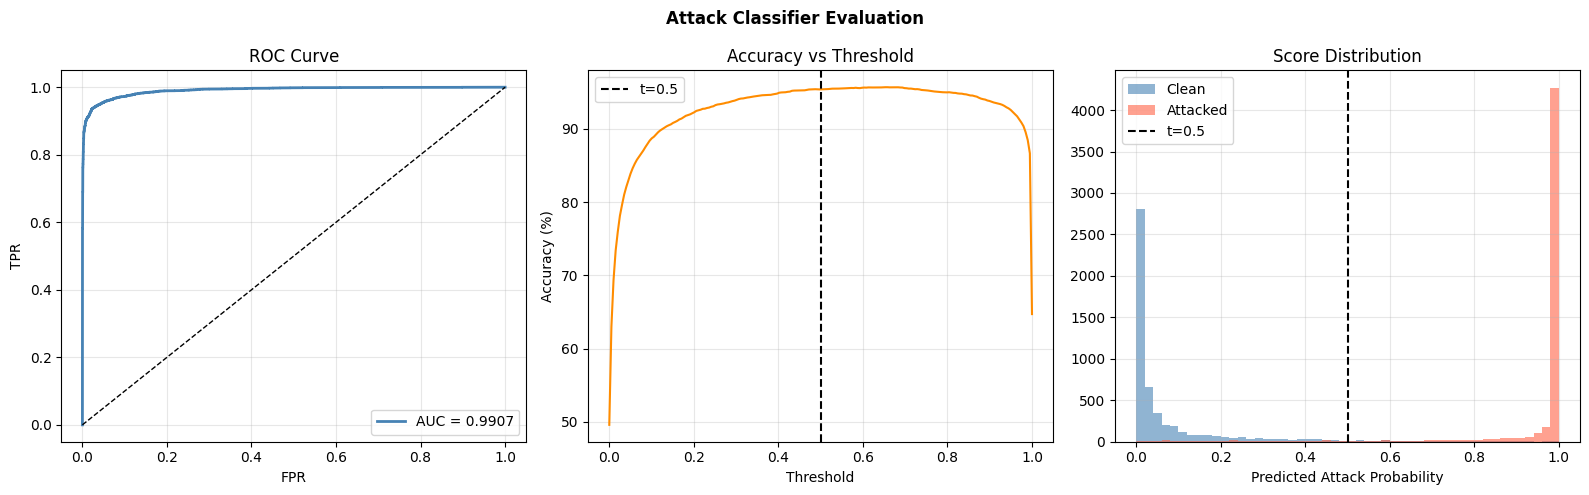

In [30]:
from sklearn.metrics import roc_curve, auc, precision_recall_fscore_support

attack_clf.eval()
det_probs, det_true = [], []
with torch.no_grad():
    for imgs, lbls in tqdm.tqdm(det_val_loader, desc='Attack clf eval'):
        probs = torch.sigmoid(attack_clf(imgs.to(device))).squeeze(1).cpu()
        det_probs.append(probs); det_true.append(lbls)

det_probs = torch.cat(det_probs).numpy()
det_true  = torch.cat(det_true).numpy().astype(int)
det_preds = (det_probs >= 0.5).astype(int)

prec, rec, f1, _ = precision_recall_fscore_support(det_true, det_preds, average='binary')
det_val_acc = 100 * (det_preds == det_true).mean()
print(f"Attack Classifier — Validation set")
print(f"  Accuracy  : {det_val_acc:.2f}%")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1        : {f1:.4f}")

fpr, tpr, _ = roc_curve(det_true, det_probs)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ROC
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy vs threshold
thresholds = np.linspace(0, 1, 200)
accs = [100*((det_probs>=t).astype(int)==det_true).mean() for t in thresholds]
axes[1].plot(thresholds, accs, color='darkorange')
axes[1].axvline(0.5, color='black', linestyle='--', label='t=0.5')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy vs Threshold'); axes[1].legend(); axes[1].grid(alpha=0.3)

# Score distribution
axes[2].hist(det_probs[det_true==0], bins=50, alpha=0.6, label='Clean',    color='steelblue')
axes[2].hist(det_probs[det_true==1], bins=50, alpha=0.6, label='Attacked', color='tomato')
axes[2].axvline(0.5, color='black', linestyle='--', label='t=0.5')
axes[2].set_xlabel('Predicted Attack Probability')
axes[2].set_title('Score Distribution'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('Attack Classifier Evaluation', fontweight='bold')
plt.tight_layout(); plt.show()


## Evaluation: Learned Denoiser

MSE and PSNR on the held-out validation set.  
Visual grid: **attacked → denoised → original**.

Denoiser eval: 100%|██████████| 167/167 [00:11<00:00, 14.75it/s]


Denoiser val MSE : 0.053807
Denoiser val PSNR: 12.69 dB


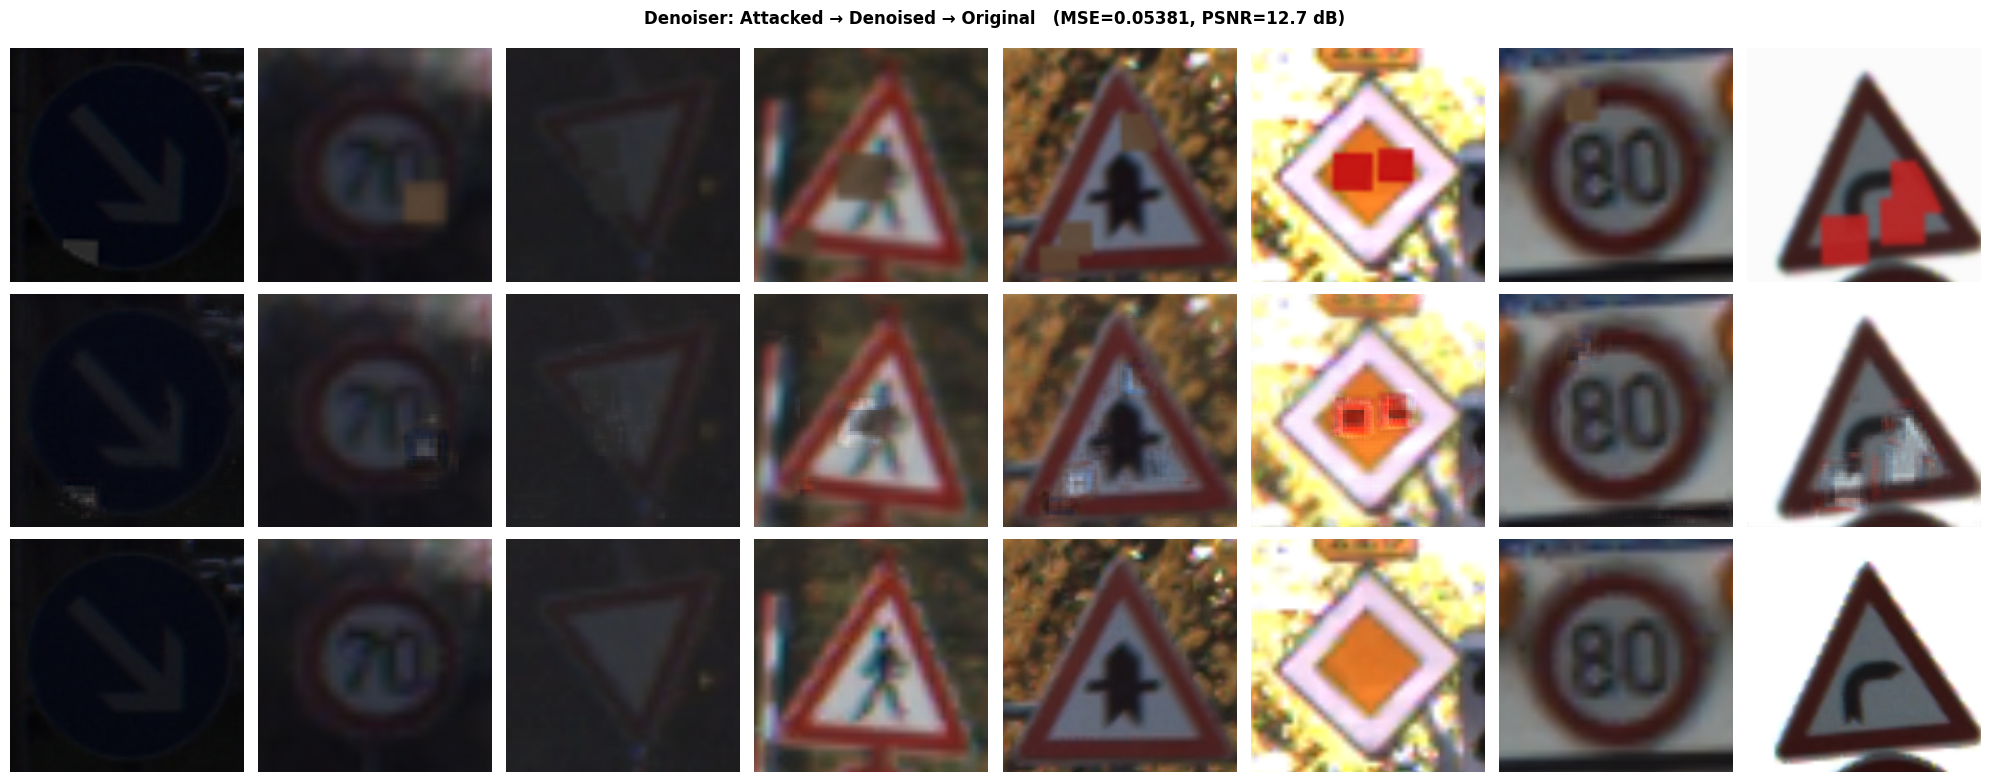

In [31]:
import math

denoiser.eval()
dn_mse_sum, dn_n = 0.0, 0
triplets = []  # (attacked, denoised, clean) tensors for display

with torch.no_grad():
    for attacked, clean in tqdm.tqdm(dn_val_loader, desc='Denoiser eval'):
        attacked, clean = attacked.to(device), clean.to(device)
        recon = denoiser(attacked)
        dn_mse_sum += ((recon - clean)**2).mean(dim=[1,2,3]).sum().item()
        dn_n += attacked.size(0)
        if len(triplets) < 8:
            for i in range(min(8 - len(triplets), attacked.size(0))):
                triplets.append((denorm(attacked[i].cpu()), denorm(recon[i].cpu()), denorm(clean[i].cpu())))

dn_mse  = dn_mse_sum / dn_n
dn_psnr = psnr(dn_mse)
print(f"Denoiser val MSE : {dn_mse:.6f}")
print(f"Denoiser val PSNR: {dn_psnr:.2f} dB")

n = len(triplets)
fig, axes = plt.subplots(3, n, figsize=(2.5*n, 8))
row_labels = ['Attacked (input)', 'Denoised (output)', 'Clean (target)']
for col, (atk, rec, cln) in enumerate(triplets):
    for row, img in enumerate([atk, rec, cln]):
        axes[row, col].imshow(img.permute(1,2,0).numpy())
        axes[row, col].axis('off')
    if col == 0:
        for row in range(3):
            axes[row, 0].set_ylabel(row_labels[row], fontsize=9)
fig.suptitle(
    f'Denoiser: Attacked → Denoised → Original   (MSE={dn_mse:.5f}, PSNR={dn_psnr:.1f} dB)',
    fontweight='bold'
)
plt.tight_layout(); plt.show()


## Evaluation: Full Pipeline Comparison

Three scenarios evaluated on the E2E validation set (clean + attacked images):

| Scenario | Description |
|---|---|
| **Baseline** | AlexNet alone, no defense |
| **Pipeline A** | Pre-trained modules assembled (no e2e) |
| **Pipeline B** | End-to-end fine-tuned |

Metrics split by **clean** vs **attacked** subsets.

Evaluating Baseline (AlexNet alone)...


Evaluating Pipeline A (pre-trained)...


Evaluating Pipeline B (e2e)...



               Scenario  Sign Acc — Clean (%)  Sign Acc — Attacked (%) Detection Acc (%)
     Baseline (AlexNet)              99.96268                96.715122                 -
Pipeline A (pretrained)              99.96268                96.601850             97.69
       Pipeline B (e2e)              99.96268                96.601850             97.69


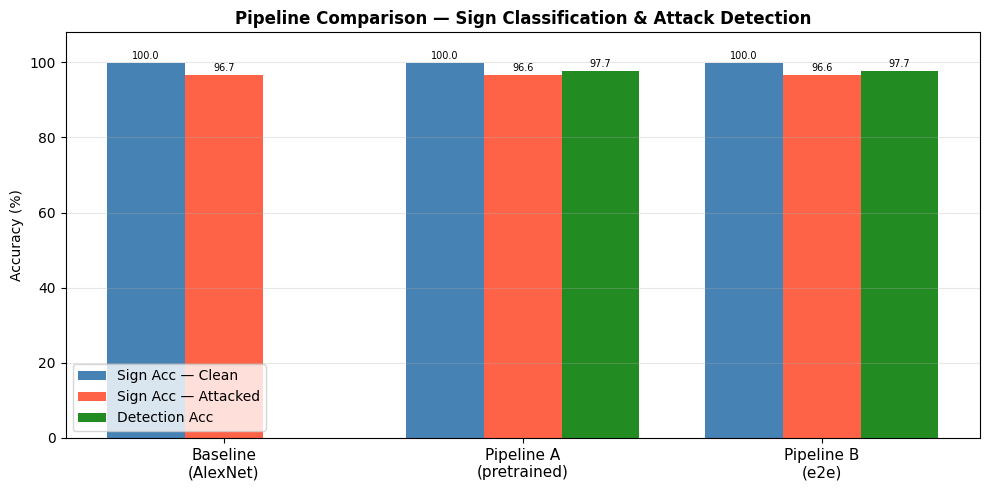

In [32]:
def eval_pipeline(mdl, loader, device, is_alexnet=False):
    """Returns (sign_acc_clean, sign_acc_attacked, detection_acc)."""
    mdl.eval()
    sc_c, sc_a, det_c, n_c, n_a = 0, 0, 0, 0, 0
    with torch.no_grad():
        for imgs, sign_lbls, atk_lbls in tqdm.tqdm(loader, desc='eval', leave=False):
            imgs = imgs.to(device)
            sign_lbls = sign_lbls.to(device)
            atk_lbls  = atk_lbls.to(device)
            if is_alexnet:
                logits = mdl(imgs)
                atk_prob = torch.zeros(imgs.size(0), 1, device=device)
            else:
                logits, atk_prob = mdl(imgs)
            preds = logits.argmax(1)
            det_p = (atk_prob.squeeze(1) >= 0.5).long()
            mask_c = atk_lbls == 0
            mask_a = atk_lbls == 1
            sc_c  += (preds[mask_c] == sign_lbls[mask_c]).sum().item()
            sc_a  += (preds[mask_a] == sign_lbls[mask_a]).sum().item()
            det_c += (det_p == atk_lbls.long()).sum().item()
            n_c   += mask_c.sum().item()
            n_a   += mask_a.sum().item()
    return (
        100 * sc_c  / max(n_c, 1),
        100 * sc_a  / max(n_a, 1),
        100 * det_c / max(n_c + n_a, 1),
    )

print("Evaluating Baseline (AlexNet alone)...")
base_c, base_a, _ = eval_pipeline(sign_clf, e2e_val_loader, device, is_alexnet=True)
print("Evaluating Pipeline A (pre-trained)...")
pa_c, pa_a, pa_d  = eval_pipeline(pipeline_a, e2e_val_loader, device)
print("Evaluating Pipeline B (e2e)...")
pb_c, pb_a, pb_d  = eval_pipeline(pipeline_b, e2e_val_loader, device)

results = pd.DataFrame({
    'Scenario':              ['Baseline (AlexNet)', 'Pipeline A (pretrained)', 'Pipeline B (e2e)'],
    'Sign Acc — Clean (%)':  [base_c, pa_c, pb_c],
    'Sign Acc — Attacked (%)': [base_a, pa_a, pb_a],
    'Detection Acc (%)':     ['-', f'{pa_d:.2f}', f'{pb_d:.2f}'],
})
print()
print(results.to_string(index=False))

# Bar chart
x = np.arange(3)
w = 0.26
labels = ['Baseline\n(AlexNet)', 'Pipeline A\n(pretrained)', 'Pipeline B\n(e2e)']
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x-w,   [base_c, pa_c, pb_c], w, label='Sign Acc — Clean',    color='steelblue')
b2 = ax.bar(x,     [base_a, pa_a, pb_a], w, label='Sign Acc — Attacked',  color='tomato')
b3 = ax.bar(x+w,   [0, pa_d, pb_d],      w, label='Detection Acc',        color='forestgreen')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 108); ax.set_ylabel('Accuracy (%)')
ax.set_title('Pipeline Comparison — Sign Classification & Attack Detection', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar in ax.patches:
    h = bar.get_height()
    if h > 1:
        ax.text(bar.get_x()+bar.get_width()/2, h+0.5, f'{h:.1f}',
                ha='center', va='bottom', fontsize=7)
plt.tight_layout(); plt.show()


### Visual: Cases Where Pipeline Corrects the Baseline

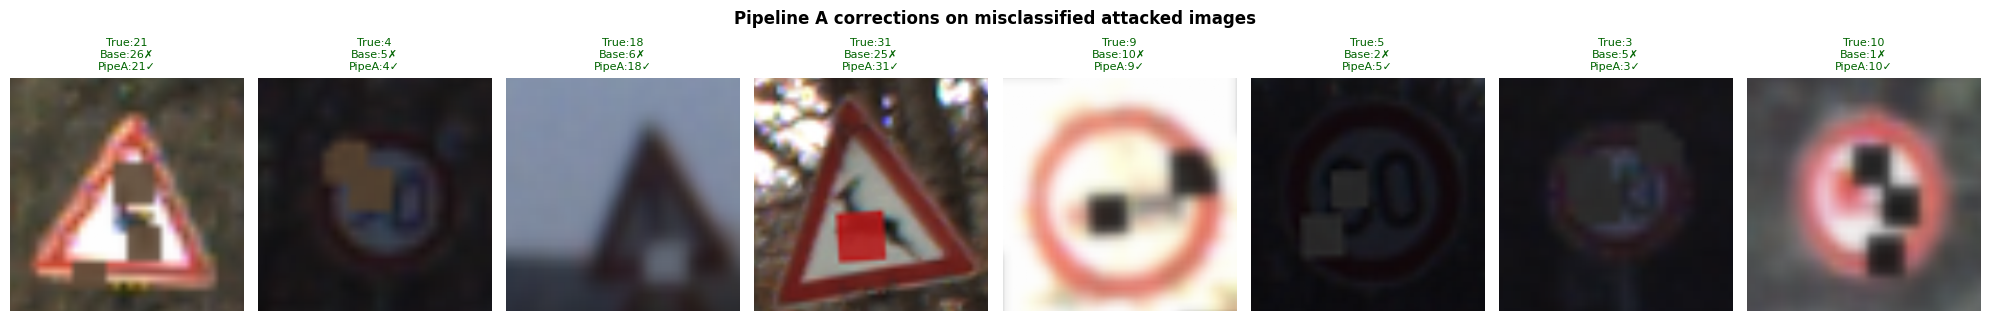

In [33]:
pipeline_a.eval(); sign_clf.eval()
examples = []

with torch.no_grad():
    for imgs, sign_lbls, atk_lbls in e2e_val_loader:
        mask_a = atk_lbls == 1
        if mask_a.sum() == 0:
            continue
        imgs_a = imgs[mask_a].to(device)
        lbls_a = sign_lbls[mask_a]
        base_p = sign_clf(imgs_a).argmax(1).cpu()
        pa_p, _ = pipeline_a(imgs_a)
        pa_p = pa_p.argmax(1).cpu()
        for i in range(imgs_a.size(0)):
            if base_p[i] != lbls_a[i] and pa_p[i] == lbls_a[i]:
                examples.append((denorm(imgs_a[i].cpu()), lbls_a[i].item(), base_p[i].item(), pa_p[i].item()))
        if len(examples) >= 8:
            break

if examples:
    n = min(len(examples), 8)
    fig, axes = plt.subplots(1, n, figsize=(2.5*n, 3.5))
    if n == 1: axes = [axes]
    for ax, (img, true, base, pa) in zip(axes, examples[:n]):
        ax.imshow(img.permute(1,2,0).numpy())
        ax.set_title(f"True:{true}\nBase:{base}✗\nPipeA:{pa}✓", fontsize=8, color='darkgreen')
        ax.axis('off')
    fig.suptitle('Pipeline A corrections on misclassified attacked images', fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    print('No correction examples found in this batch')


---
## Architecture Diagrams

Schematic diagrams of the full pipeline and each module.

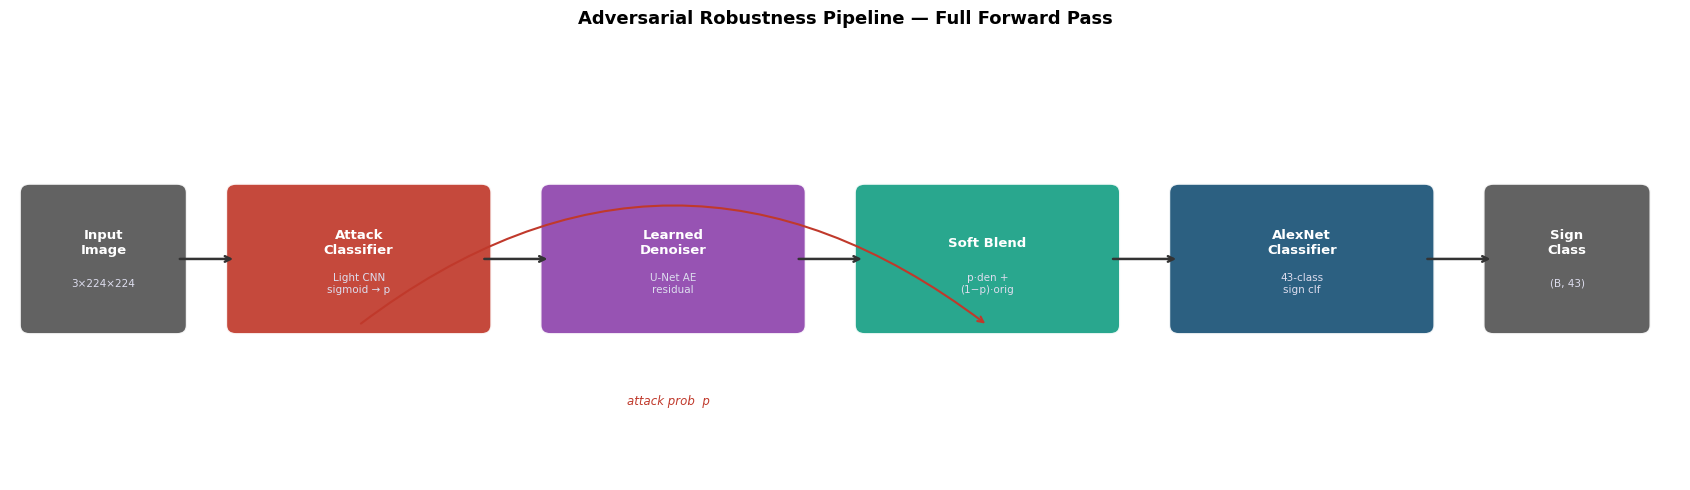

In [34]:
# Full Pipeline Flow Diagram
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(17, 5))
ax.set_xlim(0, 17); ax.set_ylim(0, 5); ax.axis('off')

def draw_box(ax, x, y, w, h, label, sub='', color='steelblue'):
    ax.add_patch(FancyBboxPatch((x,y), w, h, boxstyle='round,pad=0.1',
                                facecolor=color, edgecolor='white', lw=1.5, alpha=0.92))
    ax.text(x+w/2, y+h/2+(0.18 if sub else 0), label,
            ha='center', va='center', fontsize=9.5, fontweight='bold', color='white')
    if sub:
        ax.text(x+w/2, y+h/2-0.28, sub,
                ha='center', va='center', fontsize=7.5, color='#dde')

def draw_arrow(ax, x1, x2, y=2.5):
    ax.annotate('', xy=(x2,y), xytext=(x1,y),
                arrowprops=dict(arrowstyle='->', color='#333', lw=1.8))

draw_box(ax,  0.2, 1.75, 1.5, 1.5, 'Input\nImage',    '3×224×224',       '#555')
draw_box(ax,  2.3, 1.75, 2.5, 1.5, 'Attack\nClassifier', 'Light CNN\nsigmoid → p', '#c0392b')
draw_box(ax,  5.5, 1.75, 2.5, 1.5, 'Learned\nDenoiser',  'U-Net AE\nresidual',     '#8e44ad')
draw_box(ax,  8.7, 1.75, 2.5, 1.5, 'Soft Blend',         'p·den +\n(1−p)·orig',    '#16a085')
draw_box(ax, 11.9, 1.75, 2.5, 1.5, 'AlexNet\nClassifier','43-class\nsign clf',     '#1a5276')
draw_box(ax, 15.1, 1.75, 1.5, 1.5, 'Sign\nClass',        '(B, 43)',                 '#555')

draw_arrow(ax, 1.7, 2.3)
draw_arrow(ax, 4.8, 5.5)
draw_arrow(ax, 8.0, 8.7)
draw_arrow(ax, 11.2, 11.9)
draw_arrow(ax, 14.4, 15.1)

# p feedback from AttackClassifier to Blend
ax.annotate('', xy=(9.95, 1.75), xytext=(3.55, 1.75),
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5,
                            connectionstyle='arc3,rad=-0.38'))
ax.text(6.7, 0.85, 'attack prob  p', ha='center', fontsize=8.5,
        color='#c0392b', style='italic')

ax.set_title('Adversarial Robustness Pipeline — Full Forward Pass',
             fontsize=13, fontweight='bold', pad=10)
plt.tight_layout(); plt.show()


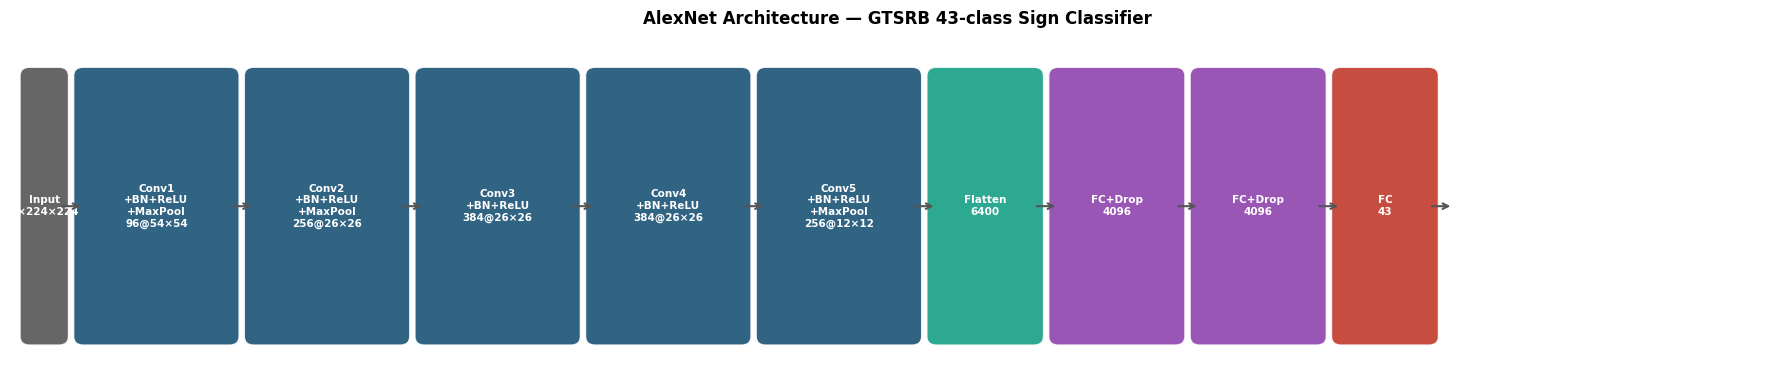

In [35]:
# AlexNet Architecture Diagram
fig, ax = plt.subplots(figsize=(18, 4))
ax.set_xlim(0, 18); ax.set_ylim(0, 4); ax.axis('off')

alexnet_layers = [
    ('Input\n3×224×224',              '#555',    0.3),
    ('Conv1\n+BN+ReLU\n+MaxPool\n96@54×54', '#1a5276', 1.5),
    ('Conv2\n+BN+ReLU\n+MaxPool\n256@26×26','#1a5276', 1.5),
    ('Conv3\n+BN+ReLU\n384@26×26',    '#1a5276', 1.5),
    ('Conv4\n+BN+ReLU\n384@26×26',    '#1a5276', 1.5),
    ('Conv5\n+BN+ReLU\n+MaxPool\n256@12×12','#1a5276', 1.5),
    ('Flatten\n6400',                  '#16a085', 1.0),
    ('FC+Drop\n4096',                  '#8e44ad', 1.2),
    ('FC+Drop\n4096',                  '#8e44ad', 1.2),
    ('FC\n43',                         '#c0392b', 0.9),
]

x = 0.1
for name, color, w in alexnet_layers:
    ax.add_patch(FancyBboxPatch((x, 0.5), w, 3.0, boxstyle='round,pad=0.1',
                                facecolor=color, edgecolor='white', lw=1.2, alpha=0.9))
    ax.text(x+w/2, 2.0, name, ha='center', va='center', fontsize=7.5, color='white', fontweight='bold')
    if x+w+0.25 < 17.9:
        ax.annotate('', xy=(x+w+0.25, 2.0), xytext=(x+w, 2.0),
                    arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))
    x += w + 0.25

ax.set_title('AlexNet Architecture — GTSRB 43-class Sign Classifier', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


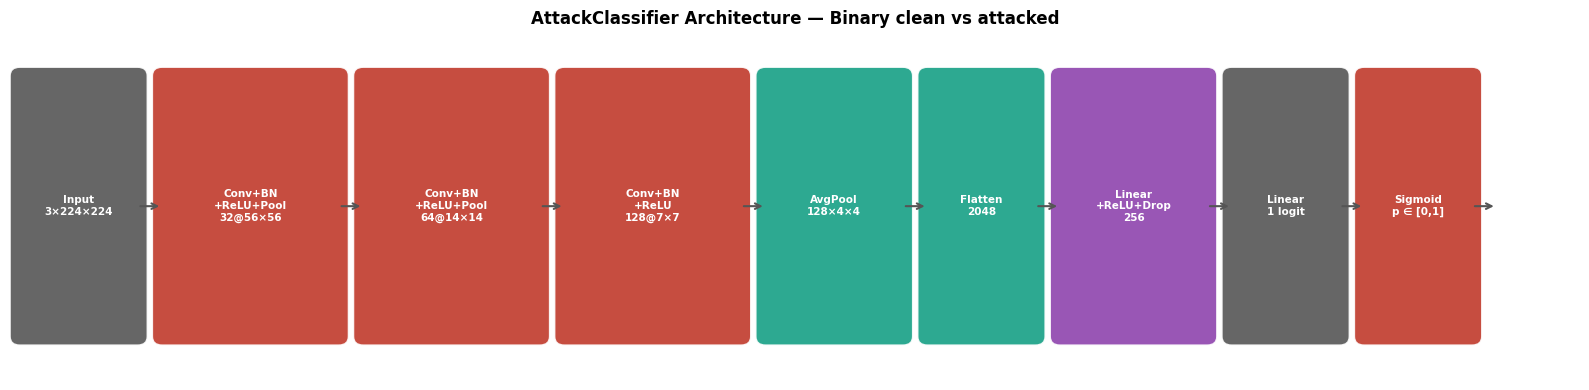

In [36]:
# AttackClassifier Architecture Diagram
fig, ax = plt.subplots(figsize=(16, 4))
ax.set_xlim(0, 16); ax.set_ylim(0, 4); ax.axis('off')

clf_layers = [
    ('Input\n3×224×224',               '#555',    1.2),
    ('Conv+BN\n+ReLU+Pool\n32@56×56',  '#c0392b', 1.8),
    ('Conv+BN\n+ReLU+Pool\n64@14×14',  '#c0392b', 1.8),
    ('Conv+BN\n+ReLU\n128@7×7',        '#c0392b', 1.8),
    ('AvgPool\n128×4×4',               '#16a085', 1.4),
    ('Flatten\n2048',                   '#16a085', 1.1),
    ('Linear\n+ReLU+Drop\n256',        '#8e44ad', 1.5),
    ('Linear\n1 logit',                '#555',    1.1),
    ('Sigmoid\np ∈ [0,1]',             '#c0392b', 1.1),
]

x = 0.1
for name, color, w in clf_layers:
    ax.add_patch(FancyBboxPatch((x, 0.5), w, 3.0, boxstyle='round,pad=0.1',
                                facecolor=color, edgecolor='white', lw=1.2, alpha=0.9))
    ax.text(x+w/2, 2.0, name, ha='center', va='center', fontsize=7.5, color='white', fontweight='bold')
    if x+w+0.25 < 15.8:
        ax.annotate('', xy=(x+w+0.25, 2.0), xytext=(x+w, 2.0),
                    arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))
    x += w + 0.25

ax.set_title('AttackClassifier Architecture — Binary clean vs attacked', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


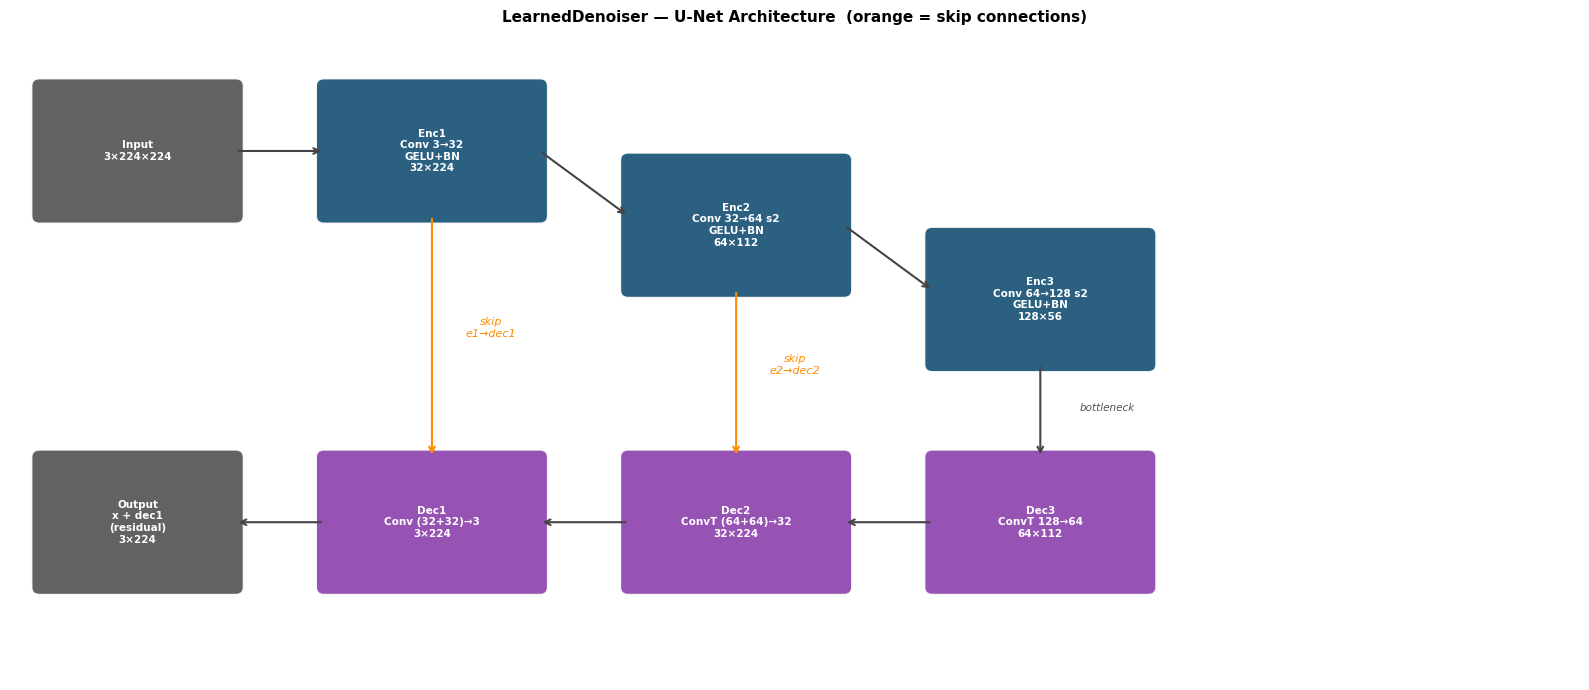

In [37]:
# LearnedDenoiser (U-Net) Architecture Diagram
fig, ax = plt.subplots(figsize=(16, 7))
ax.set_xlim(0, 16); ax.set_ylim(0, 7); ax.axis('off')
ax.set_title('LearnedDenoiser — U-Net Architecture  (orange = skip connections)',
             fontsize=11, fontweight='bold')

def ubox(ax, x, y, w, h, label, color):
    ax.add_patch(FancyBboxPatch((x,y), w, h, boxstyle='round,pad=0.08',
                                facecolor=color, edgecolor='white', lw=1.2, alpha=0.92))
    ax.text(x+w/2, y+h/2, label, ha='center', va='center',
            fontsize=7.5, color='white', fontweight='bold')

def arr(ax, x1, y1, x2, y2, color='#444', style='arc3,rad=0.0'):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5,
                                connectionstyle=style))

# Encoder row (top)
ubox(ax,  0.3, 5.0, 2.0, 1.4, 'Input\n3×224×224',          '#555')
ubox(ax,  3.2, 5.0, 2.2, 1.4, 'Enc1\nConv 3→32\nGELU+BN\n32×224', '#1a5276')
ubox(ax,  6.3, 4.2, 2.2, 1.4, 'Enc2\nConv 32→64 s2\nGELU+BN\n64×112','#1a5276')
ubox(ax,  9.4, 3.4, 2.2, 1.4, 'Enc3\nConv 64→128 s2\nGELU+BN\n128×56','#1a5276')

# Decoder row (bottom)
ubox(ax,  9.4, 1.0, 2.2, 1.4, 'Dec3\nConvT 128→64\n64×112',          '#8e44ad')
ubox(ax,  6.3, 1.0, 2.2, 1.4, 'Dec2\nConvT (64+64)→32\n32×224',      '#8e44ad')
ubox(ax,  3.2, 1.0, 2.2, 1.4, 'Dec1\nConv (32+32)→3\n3×224',         '#8e44ad')
ubox(ax,  0.3, 1.0, 2.0, 1.4, 'Output\nx + dec1\n(residual)\n3×224', '#555')

# Forward arrows encoder
arr(ax, 2.3, 5.7, 3.2, 5.7)
arr(ax, 5.4, 5.7, 6.3, 5.0)  # slight drop
arr(ax, 8.5, 4.9, 9.4, 4.2)  # slight drop
# Bottleneck down
arr(ax, 10.5, 3.4, 10.5, 2.4)
# Decoder arrows
arr(ax, 9.4, 1.7, 8.5, 1.7)
arr(ax, 6.3, 1.7, 5.4, 1.7)
arr(ax, 3.2, 1.7, 2.3, 1.7)

# Skip connections (orange dashed)
arr(ax, 4.3, 5.0, 4.3, 2.4, color='darkorange', style='arc3,rad=0.0')
arr(ax, 7.4, 4.2, 7.4, 2.4, color='darkorange', style='arc3,rad=0.0')

ax.text(4.9, 3.7, 'skip\ne1→dec1', color='darkorange', fontsize=8, style='italic', ha='center')
ax.text(8.0, 3.3, 'skip\ne2→dec2', color='darkorange', fontsize=8, style='italic', ha='center')
ax.text(10.9, 2.9, 'bottleneck', color='#555', fontsize=7.5, style='italic')

plt.tight_layout(); plt.show()


## Model Parameter Counts

In [38]:
def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

rows = [
    ('AlexNet (sign classifier)', sign_clf),
    ('AttackClassifier',          attack_clf),
    ('LearnedDenoiser',           denoiser),
]
total_all = 0
print(f"{'Module':<30} {'Total':>12} {'Trainable':>12}")
print('-' * 56)
for name, m_ in rows:
    t, tr = count_params(m_)
    total_all += t
    print(f"{name:<30} {t:>12,} {tr:>12,}")
print('-' * 56)
print(f"{'Full pipeline'::<30} {total_all:>12,}")


Module                                Total    Trainable
--------------------------------------------------------
AlexNet (sign classifier)        46,925,931   46,925,931
AttackClassifier                    618,497      618,497
LearnedDenoiser                     292,323      292,323
--------------------------------------------------------
Full pipeline:::::::::::::::::   47,836,751
